# E10 — Conformal Prediction in Twenty Lines

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Measure what an ordinary `predict()` call actually guarantees about a single prediction — and find that the answer is *nothing*
- Implement **split-conformal prediction** from its definition (a calibration split, one quantile, one comparison) and verify **90% empirical coverage** on held-out data you never touched
- Read **prediction-set size as a difficulty signal**: which individual predictions your model has earned the right to be trusted on
- Apply the identical procedure to a **regression** model to get prediction *intervals* instead of prediction *sets*
- Break the guarantee on purpose — with an over-confident model, with a per-class question, and with a time-ordered split — and say precisely which assumption each one violates

## 🔗 Where this fits

**Builds on:** Unit 2 lesson 01 `examples/01_cross_validation.ipynb` — its whole argument is that held-out
data is the only honest source of a performance claim, and that one split gives one lucky number. Conformal
prediction takes that argument one step further: it spends *one more held-out split* and buys a **guarantee**
instead of an estimate. It also builds on Unit 2 lesson 02
`examples/02_bias_variance_learning_curves.ipynb` — a learning curve describes the model *on average across
the dataset*; conformal describes *this one row in front of you*.

**Borrows forward:** the classifier below is a gradient-boosted tree (Unit 5 lesson 02
`../../unit5-model-selection/examples/02_boosting.ipynb`) producing class probabilities (Unit 3 lesson 01
`../../unit3-classification/examples/01_logistic_regression.ipynb`). If you have not reached those units yet,
treat the model as a sealed black box — **that is exactly the point of this notebook.** Conformal prediction
never opens the model.

**Used later in:** Course 05 (AIAT 115) Unit 4 lesson 07 `Course 05/unit4-ml-intro/examples/07_model_evaluation.ipynb`,
Course 11 (AIAT 125) Unit 5 lesson 01 `Course 11/unit5-pipelines-monitoring/examples/01_model_monitoring.ipynb`
(a coverage number is one of the few monitoring signals that is meaningful without labels arriving instantly),
and Course 12 (AIAT 126) Unit 4 lesson 01 `Course 12/unit4-evaluation-optimization/examples/01_model_evaluation_optimization.ipynb`,
where your graduation project has to say how sure it is.

## 🌍 A real case: the sepsis model that scored 38,455 hospitalizations

Epic Systems' **Epic Sepsis Model** was, by 2021, deployed in hundreds of U.S. hospitals. It gives every
inpatient a score; a score of 6 or higher raises an alert to a clinician. The manufacturer's internal
documentation reported an area under the ROC curve of **0.76–0.83**.

In 2021 Wong, Otles, Donnelly and colleagues at the University of Michigan externally validated it on
**27,697 patients across 38,455 hospitalizations** and published the result in *JAMA Internal Medicine*.
The measured AUC was **0.63** (95% CI 0.62–0.64). At the vendor-recommended threshold the model **alerted on
18% of all hospitalizations** — 6,971 of 38,455 — while catching **33%** of sepsis cases, at a positive
predictive value of **12%**
([doi:10.1001/jamainternmed.2021.2626](https://doi.org/10.1001/jamainternmed.2021.2626)).

Read the last two numbers again. Nearly one in five hospital stays generated an alert, and seven out of eight
of those alerts were wrong. The model was not lying — it was *scoring*, exactly as designed. What it never
did, and was never asked to do, was attach a statement of the form *"the true answer is inside this set, 90%
of the time."*

**❗ Why this lesson exists.** Everything Unit 2 has taught you so far — MSE, R², cross-validated accuracy,
learning curves — describes a model's behaviour **averaged over a dataset**. None of it tells a nurse
standing at one bedside, or an analyst looking at one row, how much to trust *that* prediction. Conformal
prediction closes exactly that gap, it costs one held-out split and about twenty lines of code, and it
works on a model you are not allowed to retrain, inspect, or even understand.

**Honest scope, stated up front.** Conformal prediction would *not* have rescued the Epic model. It cannot
make a weak model strong, and — as you will measure in Part 7 — its guarantee breaks precisely when the
deployed population drifts away from the calibration population, which is the usual hospital story. What it
would have done is make the weakness **impossible to hide**: an honest 90% prediction set from an AUC-0.63
model is so wide that nobody could have shipped it as a decision.

## 📥 Inputs & 📤 Outputs

**Inputs:** `load("border_crossing_data", prefer="sample")` — the U.S. Bureau of Transportation Statistics
record of monthly inbound crossing counts at U.S.–Canada and U.S.–Mexico ports of entry, 1996–2019. You
write no file path: the loader finds the data from any working directory and downloads it on Colab. The
full file has **346,733 rows**; what ships inside the repository, and what this notebook reads, is the
**43,818-row stratified sample** that keeps all 279 months and all 12 crossing types — so every number
below is identical on every machine, and none of them is a full-file number. Part 6 additionally uses
`load("crime_statistics")`, the same 1,994-row file Unit 2 lesson 01 cross-validates on, which ships
whole. No downloads, no network, no GPU.

The task is a genuine records-repair problem: given the port, the month, the year and the count, recover the
**`Measure`** field — which of 12 traffic categories this row counts (`Trucks`, `Truck Containers Full`,
`Bus Passengers`, `Trains`, …). Several of those categories are honestly confusable from these features
alone, which is what makes the lesson work: a good uncertainty method has to *say so*.

**Outputs:** the accuracy of an ordinary classifier; the empirical coverage of a point prediction, of a
tempting shortcut, and of a conformal set; a size-vs-accuracy table and chart; a coverage-vs-target sweep at
four confidence levels; a conformal *interval* for a regression model; and three deliberately broken
guarantees with the assumption each one violates named.

**Runtime:** about 15 seconds on an unloaded laptop CPU — most of it the two gradient-boosting fits. Expect longer if other work is running.

## Part 1: An Ordinary Model, Deliberately Not a Great One

Load the file, build six plain features, and split the data **three ways** instead of the usual two:

| split | rows | what it is for |
|---|---|---|
| **train** | 60% | fit the model — the only part the model ever sees |
| **calibration** | 20% | measure how wrong the model tends to be. **The model never sees this.** |
| **test** | 20% | check the finished guarantee. Neither the model nor the calibration touched this. |

That middle split is the entire idea. Unit 2 lesson 01 taught you to hold data back to *estimate* a score;
conformal holds data back to *set a threshold*. Everything else below is arithmetic.

In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")


Data loader ready - no file paths needed, and this works on Colab too.


In [2]:
# WHAT: load the real border-crossing file and build a 12-class tabular classification task.
# WHY:  conformal prediction wraps an ordinary supervised problem - there is nothing special about
#       the data, the model or the features. Using a real, already-bundled file (rather than a made-up
#       one) means the confusions the model makes are real confusions, not artefacts of a generator.
# WHY load(...) and not a file path: it finds the data from ANY working directory - your laptop,
#       JupyterLab opened at the repository root, or Colab where there is no repository at all - and
#       prints which copy it used.
# WHY prefer="sample": the 43,818-row extract ships inside the repository, stratified so that all 279
#       months and all 12 crossing types survive. Everyone therefore reads the same numbers, whether
#       or not they downloaded the 346,733-row original (see Course 04/datasets/DATA.md).
import numpy as np
import pandas as pd

raw = load("border_crossing_data", prefer="sample",
           usecols=["Port Code", "State", "Border", "Date", "Measure", "Value"])

# Fail loudly rather than quietly modelling the wrong thing.
if len(raw) < 40_000:
    raise RuntimeError(
        f"Expected ~43,800 rows in the bundled border-crossing sample, found {len(raw):,}. "
        "Has the file changed? See Course 04/datasets/DATA.md.")

stamp = pd.to_datetime(raw["Date"], format="%m/%d/%Y %I:%M:%S %p")
raw["year"] = stamp.dt.year
raw["month"] = stamp.dt.month
raw["log_value"] = np.log1p(raw["Value"])          # counts span 6 orders of magnitude; log makes them comparable

# State and Border are text; turn them into integer codes so the tree can treat them as categories.
from sklearn.preprocessing import OrdinalEncoder
raw[["State", "Border"]] = OrdinalEncoder().fit_transform(raw[["State", "Border"]])

print(f"Rows loaded    : {len(raw):,}   years {raw['year'].min()}-{raw['year'].max()}")
print(f"Ports of entry : {raw['Port Code'].nunique()}")
print(f"Classes to predict ({raw['Measure'].nunique()}):")
print(raw["Measure"].value_counts().to_string())


border_crossing_data: bundled 43,818-row sample of the 346,733-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified by (month, crossing type): all 279 months and all 12 crossing types survive, so the seasonal shape holds, but a 'Value' total is about 13% of the real total.


Rows loaded    : 43,818   years 1996-2019
Ports of entry : 117
Classes to predict (12):
Measure
Personal Vehicles              3822
Personal Vehicle Passengers    3819
Trucks                         3766
Truck Containers Empty         3761
Truck Containers Full          3755
Buses                          3642
Bus Passengers                 3639
Pedestrians                    3625
Trains                         3502
Rail Containers Full           3502
Rail Containers Empty          3502
Train Passengers               3483


In [3]:
# WHAT: take a 40,000-row working sample and cut it into train / calibration / test.
# WHY:  40k rows keeps the whole notebook under half a minute on a CPU, and a three-way split is what
#       separates conformal prediction from ordinary evaluation. The calibration split is held out from
#       fitting AND from the final check — it exists only to convert the model's scores into a threshold.
from sklearn.model_selection import train_test_split

FEATURES = ["log_value", "month", "year", "Port Code", "State", "Border"]
IS_CATEGORICAL = [False, False, False, True, True, True]      # last three are codes, not magnitudes

sample = raw.sample(40_000, random_state=0).reset_index(drop=True)
X = sample[FEATURES].to_numpy(dtype=float)
y = sample["Measure"].to_numpy()

# 60 / 20 / 20. Stratified, so every one of the 12 classes appears in all three parts.
X_train, X_rest, y_train, y_rest = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y)
X_cal, X_test, y_cal, y_test = train_test_split(
    X_rest, y_rest, test_size=0.5, random_state=42, stratify=y_rest)

print(f"train       : {len(X_train):,} rows  -> fits the model")
print(f"calibration : {len(X_cal):,} rows  -> sets the threshold, never seen by the model")
print(f"test        : {len(X_test):,} rows  -> checks the guarantee, never seen by either")

train       : 24,000 rows  -> fits the model
calibration : 8,000 rows  -> sets the threshold, never seen by the model
test        : 8,000 rows  -> checks the guarantee, never seen by either


In [4]:
# WHAT: fit a perfectly ordinary gradient-boosted tree and report its accuracy.
# WHY:  this is the "existing classifier" of the lesson title. Conformal prediction is going to wrap it
#       without changing a single one of its parameters. Note the accuracy honestly — it is not high, and
#       a model that is often wrong is exactly the case where knowing HOW often matters most.
import time
from sklearn.ensemble import HistGradientBoostingClassifier

t0 = time.time()
model = HistGradientBoostingClassifier(
    categorical_features=IS_CATEGORICAL, max_iter=120, random_state=0
).fit(X_train, y_train)

CLASSES = model.classes_                                   # alphabetical list of the 12 measure names
class_index = {name: i for i, name in enumerate(CLASSES)}

# Probabilities for calibration and test, and the integer label positions that go with them.
P_cal = model.predict_proba(X_cal)
P_test = model.predict_proba(X_test)
y_cal_i = np.array([class_index[v] for v in y_cal])
y_test_i = np.array([class_index[v] for v in y_test])

accuracy = float((P_test.argmax(axis=1) == y_test_i).mean())
print(f"Model fitted in {time.time() - t0:.1f}s")
print(f"Test accuracy (top-1) : {accuracy:.4f}   -> right on {accuracy:.1%} of rows")
print(f"Always guessing the most common class would give: "
      f"{pd.Series(y_test).value_counts(normalize=True).max():.4f}")

Model fitted in 2.8s
Test accuracy (top-1) : 0.4706   -> right on 47.1% of rows
Always guessing the most common class would give: 0.0875


## Part 2: The Baseline — What Does `predict()` Guarantee?

Here is the comparative experiment of this notebook, run three ways on the *same* model and the *same* test
rows. The question each time is identical:

> **How often does my answer actually contain the truth?**

**Run 1 — the point prediction.** `model.predict(x)` returns one label. The fraction of the time it contains
the truth is, by definition, the accuracy. You wanted 90%. You will not get it.

**Run 2 — the tempting shortcut.** "Fine: return the smallest group of labels whose predicted probabilities
add up to 0.90." This *feels* like it should give 90% coverage. It is what most practitioners reach for, and
it is the thing this lesson exists to argue with. It has no guarantee at all — it inherits whatever
calibration the model happens to have, and in Part 7 you will watch it collapse to nothing on a model that is
merely over-confident.

**Run 3 — split conformal.** Change exactly one thing: use the calibration split to *measure* the threshold
instead of assuming it.

In [5]:
# WHAT: measure the empirical coverage of (1) the point prediction and (2) the "sum probabilities to 0.90"
#       shortcut, on the untouched test rows.
# WHY:  coverage means: the fraction of test rows whose TRUE label is inside the answer we returned.
#       For a single label that fraction is just the accuracy. Naming it "coverage" lets us compare a point
#       prediction, a set, and an interval on one honest scale.
coverage_point = accuracy                       # a one-label answer contains the truth exactly when it is right

# The shortcut: sort each row's probabilities high-to-low and keep adding labels until they sum to >= 0.90.
order = np.argsort(-P_test, axis=1)                                   # class indices, best first
cumulative = np.take_along_axis(P_test, order, axis=1).cumsum(axis=1)
k_needed = (cumulative >= 0.90).argmax(axis=1) + 1                    # how many labels each row needed
in_shortcut_set = np.array([y_test_i[i] in order[i, :k_needed[i]] for i in range(len(y_test_i))])

coverage_shortcut = float(in_shortcut_set.mean())
size_shortcut = float(k_needed.mean())

print("TARGET: cover the true label 90% of the time.\n")
print(f"Run 1  point prediction        coverage = {coverage_point:6.1%}   answer size = 1.00 labels")
print(f"Run 2  'probabilities >= 0.90' coverage = {coverage_shortcut:6.1%}   answer size = {size_shortcut:.2f} labels")
print("\nRun 1 misses the target by a mile. Run 2 lands in the right region but overshoots it — and")
print("read Part 7 before you trust even that: nothing in Run 2 makes it land anywhere near the")
print("number you asked for, and on the next model it does not.")

TARGET: cover the true label 90% of the time.

Run 1  point prediction        coverage =  47.1%   answer size = 1.00 labels
Run 2  'probabilities >= 0.90' coverage =  94.9%   answer size = 4.15 labels

Run 1 misses the target by a mile. Run 2 lands in the right region but overshoots it — and
read Part 7 before you trust even that: nothing in Run 2 makes it land anywhere near the
number you asked for, and on the next model it does not.


## Part 3: Split Conformal Prediction — the Twenty Lines

The whole method, in words:

1. On the **calibration** split, for every row, compute a **non-conformity score**: how badly the model
   scored the label that turned out to be *correct*. The simplest such score is
   $s_i = 1 - \hat{p}(y_i \mid x_i)$ — near 0 when the model was confident and right, near 1 when it was not.
2. Take the empirical quantile $\hat q$ of those calibration scores at level
   $\lceil (n+1)(1-\alpha) \rceil / n$. (The $(n{+}1)$ and the ceiling are not decoration — they are what make
   the finite-sample guarantee exact rather than approximate.)
3. For a **new** row, return **every label whose score is at most $\hat q$**:
   $\mathcal{C}(x) = \{\,y : 1 - \hat{p}(y \mid x) \le \hat q\,\}$.

That is it. The theorem (Vovk et al.; see Angelopoulos & Bates 2022, §1) says that if the calibration rows
and the new row are **exchangeable** — drawn from the same distribution, order irrelevant — then

$$\mathbb{P}\big(y_{\text{new}} \in \mathcal{C}(x_{\text{new}})\big) \ \ge\ 1 - \alpha$$

for **any** model, **any** data distribution, and **any** finite sample size. No Gaussian assumption, no
asymptotics, no retraining, no access to the model's internals. You are about to check it.

In [6]:
# WHAT: split-conformal prediction, written out in full. Count the lines: it is twenty.
# WHY:  the method is short enough that there is no excuse for treating it as a library black box.
#       Read `conformal_quantile` as "how bad is the 90th-percentile-worst mistake I make on data I
#       have already seen", and `prediction_sets` as "keep every label at least that plausible".

def conformal_quantile(probs_cal: np.ndarray, y_cal_i: np.ndarray, alpha: float = 0.10) -> float:
    """Threshold q-hat from the calibration split. probs_cal[i, c] = model P(class c | row i)."""
    n = len(y_cal_i)
    scores = 1.0 - probs_cal[np.arange(n), y_cal_i]        # non-conformity of the TRUE label
    level = np.ceil((n + 1) * (1 - alpha)) / n             # the finite-sample correction
    return float(np.quantile(scores, min(level, 1.0), method="higher"))


def prediction_sets(probs_new: np.ndarray, q_hat: float) -> np.ndarray:
    """Boolean mask: sets[i, c] is True when class c belongs in row i's prediction set."""
    return (1.0 - probs_new) <= q_hat


def coverage_and_size(sets: np.ndarray, y_true_i: np.ndarray):
    """Empirical coverage (was the truth inside?) and average number of labels returned."""
    hit = sets[np.arange(len(y_true_i)), y_true_i]
    return float(hit.mean()), float(sets.sum(axis=1).mean())


ALPHA = 0.10                                               # we are asking for 90% coverage
q_hat = conformal_quantile(P_cal, y_cal_i, ALPHA)
conformal_sets = prediction_sets(P_test, q_hat)
coverage_conformal, size_conformal = coverage_and_size(conformal_sets, y_test_i)

print(f"q-hat (calibrated on {len(y_cal_i):,} held-out rows) = {q_hat:.4f}")
print(f"  -> keep every label the model gave at least {1 - q_hat:.4f} probability")
print(f"\nRun 3  split conformal         coverage = {coverage_conformal:6.1%}   answer size = "
      f"{size_conformal:.2f} labels")

q-hat (calibrated on 8,000 held-out rows) = 0.9216
  -> keep every label the model gave at least 0.0784 probability

Run 3  split conformal         coverage =  90.5%   answer size = 3.52 labels


In [7]:
# WHAT: put the three runs side by side and state the conclusion the printed numbers support.
# WHY:  a comparison is only honest when the model, the test rows and the target are identical across
#       runs — which they are. The only thing that changed between Run 1, Run 2 and Run 3 is what we
#       chose to RETURN.
comparison = pd.DataFrame([
    {"method": "point prediction (argmax)", "coverage": coverage_point,
     "avg labels returned": 1.0, "has a guarantee?": "no"},
    {"method": "shortcut: probabilities >= 0.90", "coverage": coverage_shortcut,
     "avg labels returned": size_shortcut, "has a guarantee?": "no"},
    {"method": f"split conformal (alpha={ALPHA})", "coverage": coverage_conformal,
     "avg labels returned": size_conformal, "has a guarantee?": "yes, if exchangeable"},
])
comparison["coverage"] = comparison["coverage"].map("{:.1%}".format)
comparison["avg labels returned"] = comparison["avg labels returned"].map("{:.2f}".format)
print(comparison.to_string(index=False))

gap = coverage_conformal - 0.90
print(f"\nConformal missed its 90% target by {gap:+.1%} on {len(y_test_i):,} test rows.")
print(f"For reference, the standard error of a coverage estimate at n={len(y_test_i):,} is about "
      f"{np.sqrt(0.9 * 0.1 / len(y_test_i)):.1%},")
print("so that gap is inside the noise. The guarantee is a lower bound in expectation, not a promise")
print("that any one test set lands exactly on 90%.")

                         method coverage avg labels returned     has a guarantee?
      point prediction (argmax)    47.1%                1.00                   no
shortcut: probabilities >= 0.90    94.9%                4.15                   no
    split conformal (alpha=0.1)    90.5%                3.52 yes, if exchangeable

Conformal missed its 90% target by +0.5% on 8,000 test rows.
For reference, the standard error of a coverage estimate at n=8,000 is about 0.3%,
so that gap is inside the noise. The guarantee is a lower bound in expectation, not a promise
that any one test set lands exactly on 90%.


## Part 4: Set Size Is a Difficulty Signal

This is the part that changes how you work.

The model above is right about **47.1% of the time overall**. That single number is what Unit 2's metrics give
you, and it is useless at the level of one decision: it says every prediction is a coin-flip-and-a-bit.

It is not. Some rows are easy and some are genuinely ambiguous, and the *size of the conformal set* tells you
which is which — before you see the answer. Group the test rows by how many labels their prediction set
contains, and look at how often the ordinary top-1 prediction was right inside each group.

In [8]:
# WHAT: group the test rows by prediction-set size, and report top-1 accuracy within each group.
# WHY:  set size is computed WITHOUT the true label, so it is available at prediction time. If accuracy
#       falls monotonically as sets grow, then set size is a usable triage signal: route the big sets to
#       a human and let the singletons through automatically.
set_size = conformal_sets.sum(axis=1)

rows = []
for size in range(1, len(CLASSES) + 1):
    mask = set_size == size
    if mask.sum() == 0:
        continue
    rows.append({
        "set size": size,
        "test rows": int(mask.sum()),
        "share": mask.mean(),
        "top-1 accuracy": float((P_test[mask].argmax(axis=1) == y_test_i[mask]).mean()),
        "coverage in group": float(conformal_sets[mask][np.arange(mask.sum()), y_test_i[mask]].mean()),
    })

size_table = pd.DataFrame(rows)
print(size_table.to_string(index=False, formatters={
    "share": "{:.1%}".format,
    "top-1 accuracy": "{:.3f}".format,
    "coverage in group": "{:.3f}".format,
}))

singletons = size_table.iloc[0]
print(f"\nRead the top row: on the {int(singletons['test rows']):,} rows where conformal returned ONE label "
      f"({singletons['share']:.1%} of the test set),")
print(f"the model's ordinary prediction was right {singletons['top-1 accuracy']:.1%} of the time — from a "
      f"model whose overall accuracy is {accuracy:.1%}.")

 set size  test rows share top-1 accuracy coverage in group
        1        917 11.5%          0.952             0.952
        2       1901 23.8%          0.714             0.948
        3       1593 19.9%          0.485             0.926
        4       1404 17.5%          0.319             0.901
        5        760  9.5%          0.192             0.828
        6        792  9.9%          0.133             0.808
        7        535  6.7%          0.093             0.880
        8         94  1.2%          0.149             0.883
        9          4  0.1%          0.000             1.000

Read the top row: on the 917 rows where conformal returned ONE label (11.5% of the test set),
the model's ordinary prediction was right 95.2% of the time — from a model whose overall accuracy is 47.1%.


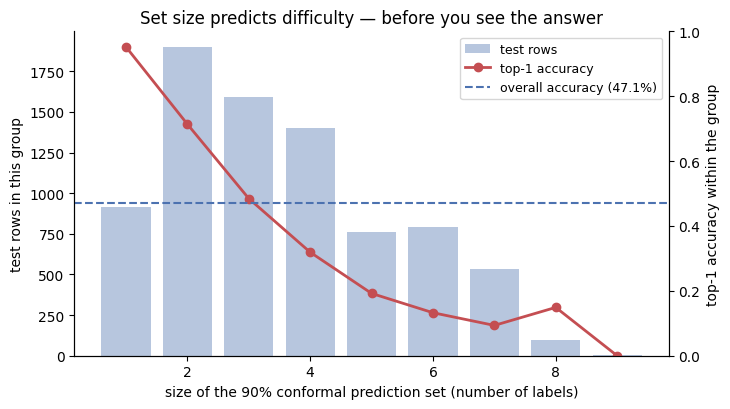

The red line falls from left to right. That is the whole result: an unlabelled, available-at-prediction-time
number that orders your rows by how much they deserve to be trusted.


In [9]:
# WHAT: draw the same table so the trend is visible at a glance.
# WHY:  a monotone fall in accuracy as set size grows is the claim; a chart is the fastest way to check
#       whether the claim survives the data rather than the sentence.
import matplotlib.pyplot as plt   # the ai-diploma kernel renders figures inline; no window is opened

fig, ax1 = plt.subplots(figsize=(7.4, 4.2))
ax1.bar(size_table["set size"], size_table["test rows"], color="#B7C6DE", label="test rows")
ax1.set_xlabel("size of the 90% conformal prediction set (number of labels)")
ax1.set_ylabel("test rows in this group")
ax1.spines[["top"]].set_visible(False)

ax2 = ax1.twinx()
ax2.plot(size_table["set size"], size_table["top-1 accuracy"], "o-", color="#C44E52",
         lw=2, label="top-1 accuracy")
ax2.axhline(accuracy, ls="--", color="#4C72B0", lw=1.5, label=f"overall accuracy ({accuracy:.1%})")
ax2.set_ylabel("top-1 accuracy within the group")
ax2.set_ylim(0, 1.0)
ax2.spines[["top"]].set_visible(False)

ax1.set_title("Set size predicts difficulty — before you see the answer")
handles = [*ax1.get_legend_handles_labels()[0], *ax2.get_legend_handles_labels()[0]]
labels = [*ax1.get_legend_handles_labels()[1], *ax2.get_legend_handles_labels()[1]]
ax1.legend(handles, labels, loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

print("The red line falls from left to right. That is the whole result: an unlabelled, "
      "available-at-prediction-time\nnumber that orders your rows by how much they deserve to be trusted.")

In [10]:
# WHAT: print a few actual prediction sets, so "a set" stops being an abstraction.
# WHY:  the labels inside a set are not random - they are the confusable family. Read the sets this cell
#       actually prints: truck categories arrive together, bus and pedestrian counts arrive together.
#       The family is visible, though it is not always tidy - which is itself honest, because the
#       features here genuinely cannot separate a bus count from a pedestrian count at some ports.
rng = np.random.default_rng(7)          # randomness here only picks WHICH examples to show
for target_size in (1, 3, 6):
    candidates = np.flatnonzero(set_size == target_size)
    if len(candidates) == 0:
        continue
    i = int(rng.choice(candidates))
    labels_in_set = [CLASSES[c] for c in np.flatnonzero(conformal_sets[i])]
    print(f"--- a test row whose prediction set has {target_size} label(s) ---")
    print(f"    true answer : {y_test[i]}")
    print(f"    top-1 guess : {CLASSES[P_test[i].argmax()]}  (p={P_test[i].max():.3f})")
    print(f"    90% set     : {{{', '.join(labels_in_set)}}}")
    print(f"    truth inside the set? {y_test[i] in labels_in_set}\n")

--- a test row whose prediction set has 1 label(s) ---
    true answer : Pedestrians
    top-1 guess : Buses  (p=0.919)
    90% set     : {Buses}
    truth inside the set? False

--- a test row whose prediction set has 3 label(s) ---
    true answer : Truck Containers Full
    top-1 guess : Truck Containers Full  (p=0.442)
    90% set     : {Bus Passengers, Truck Containers Full, Trucks}
    truth inside the set? True

--- a test row whose prediction set has 6 label(s) ---
    true answer : Trucks
    top-1 guess : Truck Containers Empty  (p=0.255)
    90% set     : {Bus Passengers, Buses, Pedestrians, Truck Containers Empty, Truck Containers Full, Trucks}
    truth inside the set? True



## Part 5: The Price of Confidence

$\alpha$ is a dial, not a constant. Ask for more coverage and the sets get wider; that trade is the honest
content of the method. Nothing else in the pipeline changes — same model, same calibration rows, same test
rows, one number.

target coverage  q-hat measured coverage avg set size of 12 labels
            80% 0.8810             79.3%         2.63          22%
            90% 0.9216             90.5%         3.52          29%
            95% 0.9479             95.2%         4.12          34%
            99% 0.9841             98.9%         5.42          45%


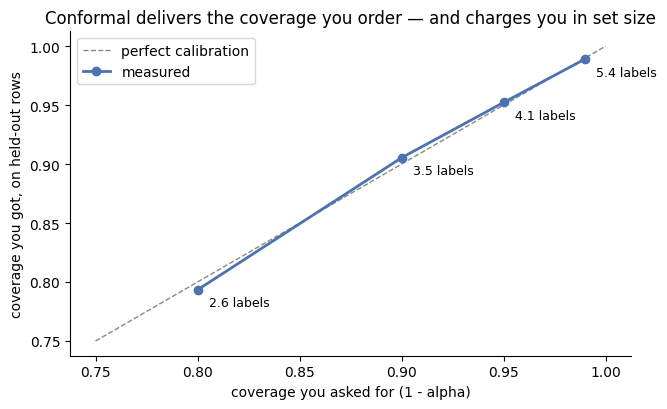

In [11]:
# WHAT: re-run the calibration at four confidence levels and record coverage and average set size.
# WHY:  this is the experiment that shows the guarantee is not a lucky coincidence at 90%. If the
#       measured coverage tracks the target across all four levels, the mechanism is real.
sweep = []
for a in (0.20, 0.10, 0.05, 0.01):
    q = conformal_quantile(P_cal, y_cal_i, a)
    cov, sz = coverage_and_size(prediction_sets(P_test, q), y_test_i)
    sweep.append({"target coverage": 1 - a, "q-hat": q, "measured coverage": cov,
                  "avg set size": sz, "of 12 labels": sz / len(CLASSES)})

sweep_df = pd.DataFrame(sweep)
print(sweep_df.to_string(index=False, formatters={
    "target coverage": "{:.0%}".format, "q-hat": "{:.4f}".format,
    "measured coverage": "{:.1%}".format, "avg set size": "{:.2f}".format,
    "of 12 labels": "{:.0%}".format}))

fig, ax = plt.subplots(figsize=(6.8, 4.2))
ax.plot([0.75, 1.0], [0.75, 1.0], ls="--", color="#888", lw=1, label="perfect calibration")
ax.plot(sweep_df["target coverage"], sweep_df["measured coverage"], "o-",
        color="#4C72B0", lw=2, label="measured")
for _, r in sweep_df.iterrows():
    ax.annotate(f"{r['avg set size']:.1f} labels",
                (r["target coverage"], r["measured coverage"]),
                textcoords="offset points", xytext=(8, -12), fontsize=9)
ax.set_xlabel("coverage you asked for (1 - alpha)")
ax.set_ylabel("coverage you got, on held-out rows")
ax.set_title("Conformal delivers the coverage you order — and charges you in set size")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Part 6: The Same Twenty Lines, for Regression

Unit 2 is a regression unit, so here is the identical procedure on a regression model — the very dataset and
the very model `examples/01_cross_validation.ipynb` cross-validates: predicting the murder rate of 1,994 US
communities from assault, urban population and rape statistics.

Only the non-conformity score changes: instead of $1 - \hat p(y\mid x)$ we use the absolute residual
$s_i = |y_i - \hat{y}_i|$. The quantile step and the guarantee are word-for-word the same, and the output is
an interval $\hat{y} \pm \hat q$ instead of a set of labels.

The baseline to beat is the textbook one: $\hat{y} \pm 1.645\,\sigma$, where $\sigma$ is the standard
deviation of the training residuals. That interval is correct **if the residuals are Gaussian**. Nobody
checks. Let us check.

In [12]:
# WHAT: split-conformal prediction intervals for a linear regression, against the textbook normal interval.
# WHY:  identical recipe, different score function. The comparison also shows what the Gaussian assumption
#       actually costs when it is wrong — here the residuals are flatter than a bell curve, so the textbook
#       interval buys coverage nobody asked for by being needlessly wide.
from sklearn.linear_model import LinearRegression
from scipy import stats

# load() again - the whole 1,994-row file ships in the repository, so this is never a sample.
crime = load("crime_statistics")
Xr = crime[["Assault", "UrbanPop", "Rape"]].to_numpy(float)
yr = crime["Murder"].to_numpy(float)

Xr_tr, Xr_rest, yr_tr, yr_rest = train_test_split(Xr, yr, test_size=0.4, random_state=42)
Xr_cal, Xr_te, yr_cal, yr_te = train_test_split(Xr_rest, yr_rest, test_size=0.5, random_state=42)

reg = LinearRegression().fit(Xr_tr, yr_tr)
pred_te = reg.predict(Xr_te)

# Baseline: assume Gaussian residuals, take +/- 1.645 sigma for a 90% interval.
sigma = (yr_tr - reg.predict(Xr_tr)).std(ddof=1)
half_normal = 1.645 * sigma
cov_normal = float((np.abs(yr_te - pred_te) <= half_normal).mean())

# Conformal: the same three steps as Part 3, with |residual| as the non-conformity score.
resid_cal = np.abs(yr_cal - reg.predict(Xr_cal))
n_cal = len(resid_cal)
q_reg = float(np.quantile(resid_cal, np.ceil((n_cal + 1) * 0.90) / n_cal, method="higher"))
cov_conf = float((np.abs(yr_te - pred_te) <= q_reg).mean())

print(f"Communities: {len(crime):,}   train {len(Xr_tr)} / calibration {len(Xr_cal)} / test {len(Xr_te)}")
print(f"Test R^2 of the linear model: {reg.score(Xr_te, yr_te):.4f}  (a weak model, on purpose)\n")
print(f"normal-theory 90% interval : +/- {half_normal:5.2f}  width {2 * half_normal:5.2f}  "
      f"measured coverage {cov_normal:.1%}")
print(f"conformal      90% interval : +/- {q_reg:5.2f}  width {2 * q_reg:5.2f}  "
      f"measured coverage {cov_conf:.1%}")

skew, kurt = stats.skew(yr_tr - reg.predict(Xr_tr)), stats.kurtosis(yr_tr - reg.predict(Xr_tr))
print(f"\nWhy they differ: the training residuals have skew {skew:+.2f} and excess kurtosis {kurt:+.2f}.")
print("A Gaussian has 0 and 0. These residuals are flatter-topped than a bell curve, so 1.645 sigma")
print(f"over-shoots — you pay {100 * (2 * half_normal / (2 * q_reg) - 1):.0f}% extra width for coverage you "
      "did not ask for.")

crime_statistics: full file, 1,994 rows.
Communities: 1,994   train 1196 / calibration 399 / test 399
Test R^2 of the linear model: 0.0989  (a weak model, on purpose)

normal-theory 90% interval : +/-  8.04  width 16.08  measured coverage 95.7%
conformal      90% interval : +/-  7.22  width 14.45  measured coverage 91.5%

Why they differ: the training residuals have skew -0.07 and excess kurtosis -1.15.
A Gaussian has 0 and 0. These residuals are flatter-topped than a bell curve, so 1.645 sigma
over-shoots — you pay 11% extra width for coverage you did not ask for.


## 💬 Discuss

1. **A set of size 6 out of 12 is an honest answer, and it is also useless to a decision-maker.** Your
   client says: "I don't want a set, I want the answer." Write the two sentences you would actually say
   back. Then decide — is the right engineering response here to widen $\alpha$, to build a better model, or
   to change the product so that a set *is* the deliverable? Argue for one.

2. **Look at the coverage-in-group column of Part 4.** Coverage is roughly 90% *overall*, but it is not 90%
   inside every set-size group, and Part 7 shows it is not 90% inside every class either. Conformal
   guarantees the average and nothing else. Name a domain in which "90% of the time, on average across
   everyone" would be an unacceptable thing to promise — and say who bears the cost of the groups that fall
   below.

3. **The calibration split cost us 8,000 rows that could have been training data.** In Part 4 the model
   reached 47.1% accuracy; with 20% more training data it would have reached slightly more. Is a guaranteed
   90% coverage from a slightly worse model a better product than an unguaranteed answer from a slightly
   better one? Does your answer change if the model is scoring loan applications rather than repairing a
   spreadsheet column?

## Part 7: Breaking It on Purpose

Three failure modes, each measured below rather than asserted.

In [13]:
# WHAT: break the guarantee three ways and measure the damage each time.
# WHY:  a method you have only ever seen succeed is a method you cannot deploy. Each block below violates
#       exactly one assumption, and the printed numbers name the price.
from sklearn.tree import DecisionTreeClassifier

print("=" * 92)
print("BREAK 1 — marginal coverage is not per-class coverage")
print("=" * 92)
per_class = []
for i, name in enumerate(CLASSES):
    mask = y_test_i == i
    per_class.append({"class": name, "test rows": int(mask.sum()),
                      "coverage": float(conformal_sets[mask][:, i].mean()),
                      "avg set size": float(conformal_sets[mask].sum(axis=1).mean())})
per_class_df = pd.DataFrame(per_class).sort_values("coverage")
print(per_class_df.to_string(index=False, formatters={
    "coverage": "{:.3f}".format, "avg set size": "{:.2f}".format}))
print(f"\nOverall coverage {coverage_conformal:.1%}; per class it runs from "
      f"{per_class_df['coverage'].min():.1%} to {per_class_df['coverage'].max():.1%}.")
print("The theorem promised the average and delivered it. It never promised the worst class.")

print("\n" + "=" * 92)
print("BREAK 2 — an over-confident model: the shortcut collapses, conformal degrades loudly")
print("=" * 92)
tree = DecisionTreeClassifier(random_state=0).fit(X_train, y_train)     # grown to purity -> probabilities are 0 or 1
Pt_cal, Pt_test = tree.predict_proba(X_cal), tree.predict_proba(X_test)
tree_acc = float((Pt_test.argmax(axis=1) == y_test_i).mean())

ord_t = np.argsort(-Pt_test, axis=1)
cum_t = np.take_along_axis(Pt_test, ord_t, axis=1).cumsum(axis=1)
k_t = (cum_t >= 0.90).argmax(axis=1) + 1
cov_short_t = float(np.mean([y_test_i[i] in ord_t[i, :k_t[i]] for i in range(len(y_test_i))]))

q_tree = conformal_quantile(Pt_cal, y_cal_i, ALPHA)
cov_tree, size_tree = coverage_and_size(prediction_sets(Pt_test, q_tree), y_test_i)

print(f"single decision tree: accuracy {tree_acc:.1%}, mean top probability {Pt_test.max(axis=1).mean():.3f} "
      "(a boosted ensemble averages; one tree does not)")
print(f"  shortcut 'probabilities >= 0.90' : coverage {cov_short_t:.1%}, avg size {k_t.mean():.2f} "
      "  <- asked for 90%, got the accuracy")
print(f"  split conformal (alpha={ALPHA})     : coverage {cov_tree:.1%}, avg size {size_tree:.2f} of "
      f"{len(CLASSES)}   <- kept its promise by returning everything")
print("\nConformal did not fail here; it told the truth in the only way it can. A method that cannot")
print("separate the classes gets a set containing all of them. That is a usable alarm, not a bug.")

print("\n" + "=" * 92)
print("BREAK 3 — exchangeability: calibrate on the past, deploy on the future")
print("=" * 92)
years = sample["year"].to_numpy()
i_tr = np.flatnonzero(years <= 2011)
i_cal = np.flatnonzero((years >= 2012) & (years <= 2013))
i_te = np.flatnonzero(years >= 2016)

drift_model = HistGradientBoostingClassifier(
    categorical_features=IS_CATEGORICAL, max_iter=120, random_state=0).fit(X[i_tr], y[i_tr])
di = {name: k for k, name in enumerate(drift_model.classes_)}
Pd_cal, Pd_te = drift_model.predict_proba(X[i_cal]), drift_model.predict_proba(X[i_te])
yd_cal = np.array([di[v] for v in y[i_cal]])
yd_te = np.array([di[v] for v in y[i_te]])

q_drift = conformal_quantile(Pd_cal, yd_cal, ALPHA)
cov_drift, size_drift = coverage_and_size(prediction_sets(Pd_te, q_drift), yd_te)
print(f"train <=2011 ({len(i_tr):,} rows) | calibrate 2012-2013 ({len(i_cal):,}) | test >=2016 ({len(i_te):,})")
print(f"  accuracy {float((Pd_te.argmax(axis=1) == yd_te).mean()):.1%}, "
      f"coverage {cov_drift:.1%} against a 90% target, avg set size {size_drift:.2f}")
print(f"\nShortfall: {cov_drift - 0.90:+.1%}. Nothing in the code changed — only the assumption that")
print("calibration rows and test rows come from the same distribution, which time quietly broke.")

BREAK 1 — marginal coverage is not per-class coverage
                      class  test rows coverage avg set size
             Bus Passengers        667    0.802         3.90
                      Buses        668    0.861         3.34
      Truck Containers Full        682    0.871         3.62
                Pedestrians        663    0.873         3.71
     Truck Containers Empty        685    0.874         3.60
       Rail Containers Full        636    0.901         4.50
      Rail Containers Empty        638    0.918         4.51
           Train Passengers        637    0.931         4.56
                     Trains        632    0.938         4.11
                     Trucks        693    0.952         3.15
Personal Vehicle Passengers        699    0.969         1.74
          Personal Vehicles        700    0.970         1.90

Overall coverage 90.5%; per class it runs from 80.2% to 97.0%.
The theorem promised the average and delivered it. It never promised the worst class.

BR

train <=2011 (28,537 rows) | calibrate 2012-2013 (3,694) | test >=2016 (4,100)
  accuracy 48.5%, coverage 84.4% against a 90% target, avg set size 2.88

Shortfall: -5.6%. Nothing in the code changed — only the assumption that
calibration rows and test rows come from the same distribution, which time quietly broke.


## ⚠️ Where this breaks

**Coverage is marginal, not conditional — and the printed table proves it.** Averaged over the test set the
sets cover 90.5% of the time. Per class it ranges from 80.2% (`Bus Passengers`) to 97.0%
(`Personal Vehicles`). If your fairness or safety argument needs "90% for *this* group", plain split
conformal does not give it to you. The adaptive-score method of Romano, Sesia & Candès (2020) and the
group-balanced variants in Angelopoulos & Bates (2022, §4) exist precisely for this, and they cost more
calibration data.

**Exchangeability is a real assumption and time destroys it.** Calibrating on 2012–2013 and testing on
2016 onward dropped coverage to 84.4% against a 90% target — a 5.6-point shortfall from nothing but the
calendar. Every deployed model faces this. Barber, Candès, Ramdas & Tibshirani (2022) generalize conformal
to weighted, non-exchangeable data; the practical version in Course 11 Unit 5 is: **re-calibrate on recent
data, on a schedule, and monitor the coverage number as a first-class metric.**

**A guarantee is not a good model.** The single decision tree kept its 100% coverage promise by returning
all 12 labels on every row. Conformal converts a bad model into a *visibly* bad model; it does not convert
it into a good one. If your sets are wide, the fix is upstream — better features, better model — not a
different quantile.

**Small calibration sets make the guarantee loose.** The bound is
$1-\alpha \le \mathbb{P}(y \in \mathcal{C}(x)) \le 1-\alpha+\frac{1}{n+1}$, so with $n = 100$ calibration
rows your realized coverage can sit a full percentage point above target, and the *variability* of coverage
across different calibration draws is much larger still (Angelopoulos & Bates 2022, §3 works this out). In
practice, quote a coverage figure only from calibration sets in the high hundreds upward; we used 8,000.

**Never look at the test split while choosing the score.** We chose $1 - \hat p$ up front. Trying five score
functions and reporting the one whose test coverage looked best is fitting the test set — the same sin Unit 2
lesson 01 warns about, wearing a new hat.

**The sets are only as meaningful as the label set.** Twelve traffic measures are mutually exclusive and
exhaustive here. When labels overlap, or the true answer is not among the classes at all, "the truth is in
the set 90% of the time" is a sentence about your label schema, not about the world.

## ✅ Summary

**What you actually did** (every number computed live above, on 8,000 held-out rows the model never saw):

- Fitted an ordinary 12-class classifier on real border-crossing records and measured its accuracy: **47.1%**
- Showed that its point prediction covers the truth **47.1%** of the time when you asked for 90%
- Implemented split conformal in twenty lines and got **90.5%** coverage with an average of **3.52** labels
  per answer, against a 90% target
- Found that set size ranks difficulty: on the **917** rows (11.5%) where the set held one label, the model's
  top-1 guess was right **95.2%** of the time — from a model that is right 47.1% of the time overall
- Swept the confidence dial: **79.3% / 90.5% / 95.2% / 98.9%** measured against targets of 80 / 90 / 95 / 99,
  at an average cost of **2.63 / 3.52 / 4.12 / 5.42** labels
- Applied the identical recipe to a linear regression and got a **91.5%**-covering interval that is **11%
  narrower** than the textbook Gaussian one
- Broke the guarantee three times and named the assumption each break violated

**The one sentence to keep:** conformal prediction does not make your model better — it makes your model's
uncertainty *checkable*, at the cost of one held-out split and about twenty lines, on any model you can call
`predict_proba` on.

**Where this goes next.** The same machinery gives risk control beyond coverage (bounded false-negative rate),
conformal intervals for quantile regression, and conformal p-values for outlier detection. In 2026 it is the
default answer to "how sure is the model" in regulated deployments, precisely because it needs no
distributional assumption to defend in an audit.

## 📚 References

Verified citations. Conformal prediction is old (Vovk and colleagues, late 1990s); what changed is that it
became routine engineering.

1. Angelopoulos, A. N., & Bates, S. (2021, rev. 2022). *A Gentle Introduction to Conformal Prediction and
   Distribution-Free Uncertainty Quantification*. [arXiv:2107.07511](https://arxiv.org/abs/2107.07511) —
   the reference text for everything in this notebook; §1 contains the split-conformal recipe implemented in
   Part 3, and the paper's own worked examples ship as runnable notebooks.
2. Romano, Y., Sesia, M., & Candès, E. J. (2020). *Classification with Valid and Adaptive Coverage*.
   [arXiv:2006.02544](https://arxiv.org/abs/2006.02544) — the adaptive (APS) score, designed to give
   approximate *conditional* coverage where the score used in Part 3 gives only marginal coverage.
3. Angelopoulos, A., Bates, S., Malik, J., & Jordan, M. I. (2020). *Uncertainty Sets for Image Classifiers
   using Conformal Prediction*. [arXiv:2009.14193](https://arxiv.org/abs/2009.14193) — RAPS; reports sets
   "often factors of 5 to 10 smaller" than a Platt-scaling baseline at the same coverage on ImageNet.
4. Barber, R. F., Candès, E. J., Ramdas, A., & Tibshirani, R. J. (2022). *Conformal prediction beyond
   exchangeability*. [arXiv:2202.13415](https://arxiv.org/abs/2202.13415) — weighted quantiles for the
   drifting-data case you measured in Break 3.
5. Wong, A., Otles, E., Donnelly, J. P., et al. (2021). *External Validation of a Widely Implemented
   Proprietary Sepsis Prediction Model in Hospitalized Patients*. **JAMA Internal Medicine** 181(8),
   1065–1070. [doi:10.1001/jamainternmed.2021.2626](https://doi.org/10.1001/jamainternmed.2021.2626) — the
   case in the opening section: AUC 0.63 in external validation, alerts on 18% of 38,455 hospitalizations.
6. U.S. Bureau of Transportation Statistics. *Border Crossing/Entry Data* — the dataset used here, read
   with `load("border_crossing_data", prefer="sample")`; the 43,818-row stratified sample ships in the
   repository and the 346,733-row original is on Kaggle as `akhilv11/us-border-crossing-data`. See
   `Course 04/datasets/DATA.md`.